# Versao 10 - Classificacao Multiclasse Com LSTM Multitarefa

Este e o notebook central da `versao10`. Aqui a pergunta experimental e direta: uma arquitetura recorrente, agora alinhada ao artigo do dataset, consegue reduzir o gap restante para `RandomForest` e `XGBoost`?

## Resultados Da Ultima Execucao Registrada

Os artefatos atuais da `versao10` mostram:

- o treinamento foi encerrado apos `23` epocas, com melhor checkpoint na epoca `13`
- na melhor epoca, o `macro-F1` de treino foi `0.9587` e o de validacao foi `0.9646`; em outras palavras, o `macro-F1` de validacao ficou `0.0060` acima do treino, o que indica que a regularizacao e a estrategia multitarefa nao produziram um quadro de sobreajuste evidente
- validacao: `accuracy = 0.9581`, `macro-F1 = 0.9646`, `balanced accuracy = 0.9599`
- teste: `accuracy = 0.9373`, `macro-F1 = 0.9409`, `balanced accuracy = 0.9572`
- variacao sobre a `versao9`: `0.0149` em `accuracy`, `0.0140` em `macro-F1` e `0.0157` em `balanced accuracy`
- variacao sobre a melhor `LSTM` anterior da `versao6`: `-0.0060` em `accuracy`, `0.0223` em `macro-F1` e `0.0205` em `balanced accuracy`
- classes mais dificeis no teste: classe `7` com `F1 = 0.7778` e `recall = 1.0000`; classe `4` com `F1 = 0.8547` e `recall = 0.9615`; classe `1` com `F1 = 0.8889` e `recall = 0.8000`
- maiores ganhos de `F1` sobre a `versao9`: classe `3` com `+0.0588` em `F1`, classe `4` com `+0.0380` em `F1`, classe `7` com `+0.0278` em `F1`, classe `0` com `+0.0216` em `F1`

Interpretacao atual: a `versao10` se tornou a melhor rede recorrente do projeto em `macro-F1` e `balanced accuracy`. O ganho, portanto, ja nao parece ser fruto de apenas mais profundidade; ele esta coerente com a hipotese de que usar melhor a estrutura do dataset realmente ajuda.

## Motivacao imediata

A `versao9` terminou com `accuracy = 0.9224`, `macro-F1 = 0.9268` e `balanced accuracy = 0.9415`. A `versao10` nasce para tentar converter esse ganho parcial em superacao efetiva das baselines.

                ## Classe principal explicitamente documentada

                Para que a arquitetura fique transparente no proprio notebook, a definicao da classe principal aparece abaixo.

                ```python
                class SourceAwareMultitaskTemporalModel(nn.Module):
    def __init__(
        self,
        input_size: int,
        tabular_size: int,
        num_classes: int,
        num_step_classes: int,
        num_state_classes: int,
        source_vocab_size: int,
        *,
        hidden_size: int = 128,
        num_layers: int = 2,
        source_embedding_dim: int = 8,
        tabular_hidden_size: int = 128,
        dropout: float = 0.25,
    ) -> None:
        super().__init__()
        self.hidden_size = int(hidden_size)
        self.source_embedding_dim = int(source_embedding_dim)
        augmented_input_size = input_size * 3

        self.source_embedding = nn.Embedding(source_vocab_size, self.source_embedding_dim)
        self.input_norm = nn.LayerNorm(augmented_input_size)
        self.input_projection = nn.Linear(augmented_input_size, self.hidden_size)
        self.local_conv = nn.Sequential(
            nn.Conv1d(self.hidden_size, self.hidden_size, kernel_size=5, padding=2),
            nn.GELU(),
            nn.Conv1d(self.hidden_size, self.hidden_size, kernel_size=5, padding=2),
            nn.GELU(),
        )
        self.context_encoder = nn.LSTM(
            input_size=self.hidden_size + self.source_embedding_dim,
            hidden_size=self.hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
            bidirectional=True,
        )
        context_dim = self.hidden_size * 2
        self.context_norm = nn.LayerNorm(context_dim)
        self.step_class_head = nn.Sequential(
            nn.Linear(context_dim, context_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(context_dim, num_step_classes),
        )
        self.step_state_head = nn.Sequential(
            nn.Linear(context_dim, context_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(context_dim, num_state_classes),
        )
        self.attention_score = nn.Linear(context_dim, 1)
        self.tabular_branch = nn.Sequential(
            nn.LayerNorm(tabular_size),
            nn.Linear(tabular_size, tabular_hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(tabular_hidden_size, tabular_hidden_size),
            nn.GELU(),
        )
        fusion_dim = context_dim * 3 + tabular_hidden_size + self.source_embedding_dim
        self.classifier = nn.Sequential(
            nn.LayerNorm(fusion_dim),
            nn.Linear(fusion_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(
        self,
        x_seq: torch.Tensor,
        x_tab: torch.Tensor,
        x_missing: torch.Tensor,
        x_frozen: torch.Tensor,
        source_id: torch.Tensor,
    ) -> dict[str, torch.Tensor]:
        augmented = torch.cat([x_seq, x_missing, x_frozen], dim=-1)
        projected = self.input_projection(self.input_norm(augmented))
        conv_features = self.local_conv(projected.transpose(1, 2)).transpose(1, 2)
        local_features = projected + conv_features

        source_embedding = self.source_embedding(source_id)
        source_context = source_embedding.unsqueeze(1).expand(-1, local_features.size(1), -1)
        encoder_input = torch.cat([local_features, source_context], dim=-1)
        sequence_output, (hidden_state, _) = self.context_encoder(encoder_input)
        sequence_output = self.context_norm(sequence_output)

        step_class_logits = self.step_class_head(sequence_output)
        step_state_logits = self.step_state_head(sequence_output)

        forward_last = hidden_state[-2]
        backward_last = hidden_state[-1]
        last_hidden = torch.cat([forward_last, backward_last], dim=1)
        mean_pool = sequence_output.mean(dim=1)
        attention_logits = self.attention_score(sequence_output).squeeze(-1)
        attention_weights = torch.softmax(attention_logits, dim=1).unsqueeze(-1)
        attention_pool = torch.sum(sequence_output * attention_weights, dim=1)

        tabular_features = self.tabular_branch(x_tab)
        fused = torch.cat(
            [last_hidden, mean_pool, attention_pool, tabular_features, source_embedding],
            dim=1,
        )
        instance_logits = self.classifier(fused)
        return {
            "instance_logits": instance_logits,
            "step_class_logits": step_class_logits,
            "step_state_logits": step_state_logits,
        }
                ```

                ## Rotina de treinamento explicitamente documentada

                O treinamento tambem fica visivel, inclusive com as perdas auxiliares sobre `class` e `state`.

                ```python
                def train_multitask_temporal_model(
    X_train_seq: np.ndarray,
    X_train_tab: np.ndarray,
    X_train_missing: np.ndarray,
    X_train_frozen: np.ndarray,
    y_train: np.ndarray,
    y_train_step_class: np.ndarray,
    y_train_step_state: np.ndarray,
    train_source_id: np.ndarray,
    X_val_seq: np.ndarray,
    X_val_tab: np.ndarray,
    X_val_missing: np.ndarray,
    X_val_frozen: np.ndarray,
    y_val: np.ndarray,
    y_val_step_class: np.ndarray,
    y_val_step_state: np.ndarray,
    val_source_id: np.ndarray,
    *,
    output_dir: str | Path,
    class_labels: list[int],
    observation_class_codes: list[int],
    observation_state_codes: list[int],
    source_vocab_size: int,
    hidden_size: int = 128,
    num_layers: int = 2,
    source_embedding_dim: int = 8,
    tabular_hidden_size: int = 128,
    dropout: float = 0.25,
    learning_rate: float = 5e-4,
    weight_decay: float = 1e-4,
    batch_size: int = 64,
    epochs: int = 55,
    patience: int = 10,
    lambda_step_class: float = 0.35,
    lambda_step_state: float = 0.15,
    random_state: int = 42,
    device: str | None = None,
) -> MultiTaskTrainingSummary:
    require_classification_stack()
    require_torch()

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    set_seed(random_state)
    device_obj = _default_device(device)

    model = SourceAwareMultitaskTemporalModel(
        input_size=int(X_train_seq.shape[-1]),
        tabular_size=int(X_train_tab.shape[-1]),
        num_classes=len(class_labels),
        num_step_classes=len(observation_class_codes),
        num_state_classes=len(observation_state_codes),
        source_vocab_size=source_vocab_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        source_embedding_dim=source_embedding_dim,
        tabular_hidden_size=tabular_hidden_size,
        dropout=dropout,
    ).to(device_obj)

    instance_weight_values = _compute_balanced_class_weights(class_labels, y_train)
    step_class_weight_values = _compute_balanced_index_weights(
        len(observation_class_codes),
        y_train_step_class.reshape(-1),
    )
    step_state_weight_values = _compute_balanced_index_weights(
        len(observation_state_codes),
        y_train_step_state.reshape(-1),
    )

    instance_criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(instance_weight_values, dtype=torch.float32, device=device_obj)
    )
    step_class_criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(step_class_weight_values, dtype=torch.float32, device=device_obj),
        ignore_index=IGNORE_INDEX,
    )
    step_state_criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(step_state_weight_values, dtype=torch.float32, device=device_obj),
        ignore_index=IGNORE_INDEX,
    )

    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=max(patience // 2, 1),
    )

    train_sampler = _build_weighted_sampler(y_train, class_labels)
    train_loader = _multitask_loader(
        X_train_seq,
        X_train_tab,
        X_train_missing,
        X_train_frozen,
        y_train,
        y_train_step_class,
        y_train_step_state,
        train_source_id,
        batch_size=batch_size,
        sampler=train_sampler,
    )

    checkpoint_path = output_dir / "multitask_temporal_best.pt"
    config_path = output_dir / "multitask_temporal_config.json"
    history_path = output_dir / "multitask_temporal_history.csv"

    history_rows = []
    best_signature: tuple[float, float, float] | None = None
    best_epoch = 0
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_losses = []
        epoch_instance_losses = []
        epoch_step_class_losses = []
        epoch_step_state_losses = []

        for (
            batch_seq,
            batch_tab,
            batch_missing,
            batch_frozen,
            batch_y,
            batch_step_class,
            batch_step_state,
            batch_source,
        ) in train_loader:
            batch_seq = batch_seq.to(device_obj, non_blocking=True)
            batch_tab = batch_tab.to(device_obj, non_blocking=True)
            batch_missing = batch_missing.to(device_obj, non_blocking=True)
            batch_frozen = batch_frozen.to(device_obj, non_blocking=True)
            batch_y = batch_y.to(device_obj, non_blocking=True)
            batch_step_class = batch_step_class.to(device_obj, non_blocking=True)
            batch_step_state = batch_step_state.to(device_obj, non_blocking=True)
            batch_source = batch_source.to(device_obj, non_blocking=True)

            outputs = model(batch_seq, batch_tab, batch_missing, batch_frozen, batch_source)
            instance_loss = instance_criterion(outputs["instance_logits"], batch_y)
            step_class_loss = step_class_criterion(
                outputs["step_class_logits"].reshape(-1, len(observation_class_codes)),
                batch_step_class.reshape(-1),
            )
            step_state_loss = step_state_criterion(
                outputs["step_state_logits"].reshape(-1, len(observation_state_codes)),
                batch_step_state.reshape(-1),
            )
            loss = instance_loss + lambda_step_class * step_class_loss + lambda_step_state * step_state_loss

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_losses.append(float(loss.detach().cpu().item()))
            epoch_instance_losses.append(float(instance_loss.detach().cpu().item()))
            epoch_step_class_losses.append(float(step_class_loss.detach().cpu().item()))
            epoch_step_state_losses.append(float(step_state_loss.detach().cpu().item()))

        train_pred = predict_multitask_model_classes(
            model,
            X_train_seq,
            X_train_tab,
            X_train_missing,
            X_train_frozen,
            train_source_id,
            batch_size=batch_size,
            device=str(device_obj),
        )
        val_pred = predict_multitask_model_classes(
            model,
            X_val_seq,
            X_val_tab,
            X_val_missing,
            X_val_frozen,
            val_source_id,
            batch_size=batch_size,
            device=str(device_obj),
        )

        train_eval = evaluate_predictions(y_train, train_pred, class_labels=class_labels)
        val_eval = evaluate_predictions(y_val, val_pred, class_labels=class_labels)

        current_row = {
            "epoch": epoch,
            "learning_rate": float(optimizer.param_groups[0]["lr"]),
            "train_loss": float(np.mean(epoch_losses)),
            "train_instance_loss": float(np.mean(epoch_instance_losses)),
            "train_step_class_loss": float(np.mean(epoch_step_class_losses)),
            "train_step_state_loss": float(np.mean(epoch_step_state_losses)),
            "train_accuracy": train_eval["accuracy"],
            "train_macro_f1": train_eval["macro_f1"],
            "train_balanced_accuracy": train_eval["balanced_accuracy"],
            "val_accuracy": val_eval["accuracy"],
            "val_macro_f1": val_eval["macro_f1"],
            "val_balanced_accuracy": val_eval["balanced_accuracy"],
        }
        history_rows.append(current_row)

        scheduler.step(val_eval["macro_f1"])
        current_signature = (
            float(val_eval["macro_f1"]),
            float(val_eval["balanced_accuracy"]),
            float(val_eval["accuracy"]),
        )
        if best_signature is None or current_signature > best_signature:
            best_signature = current_signature
            best_epoch = epoch
            patience_counter = 0
            torch.save(model.state_dict(), checkpoint_path)
            _write_json(
                {
                    "input_size": int(X_train_seq.shape[-1]),
                    "tabular_size": int(X_train_tab.shape[-1]),
                    "num_classes": len(class_labels),
                    "num_step_classes": len(observation_class_codes),
                    "num_state_classes": len(observation_state_codes),
                    "source_vocab_size": source_vocab_size,
                    "hidden_size": hidden_size,
                    "num_layers": num_layers,
                    "source_embedding_dim": source_embedding_dim,
                    "tabular_hidden_size": tabular_hidden_size,
                    "dropout": dropout,
                    "checkpoint_path": str(checkpoint_path),
                },
                config_path,
            )
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    pd.DataFrame(history_rows).to_csv(history_path, index=False)
    best_history_row = pd.DataFrame(history_rows).loc[lambda df: df["epoch"] == best_epoch].iloc[0]
    return MultiTaskTrainingSummary(
        model_name="source_aware_multitask_temporal_model",
        checkpoint_path=str(checkpoint_path),
        config_path=str(config_path),
        history_path=str(history_path),
        best_epoch=int(best_epoch),
        best_val_macro_f1=float(best_history_row["val_macro_f1"]),
        best_val_accuracy=float(best_history_row["val_accuracy"]),
        best_val_balanced_accuracy=float(best_history_row["val_balanced_accuracy"]),
    )
                ```

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
PROJECT_ROOT = ROOT.parent if ROOT.name == "versao10" else ROOT
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from versao10.pipeline_v10 import (
    SourceAwareMultitaskTemporalModel,
    evaluate_predictions,
    export_evaluation_artifacts,
    load_bundle,
    load_multitask_temporal_model,
    load_split_arrays,
    plot_confusion_matrix_for_predictions,
    predict_multitask_model_classes,
    train_multitask_temporal_model,
)

RUN_DIR = PROJECT_ROOT / "artifacts" / "reports_v10" / "classificacao_v10_multitarefa"
LSTM_DIR = RUN_DIR / "lstm"

In [2]:
bundle = load_bundle(RUN_DIR / "bundle_v10.json")
train_arrays = load_split_arrays(RUN_DIR / "train_arrays.npz")
validation_arrays = load_split_arrays(RUN_DIR / "validation_arrays.npz")
test_arrays = load_split_arrays(RUN_DIR / "test_arrays.npz")

model = SourceAwareMultitaskTemporalModel(
    input_size=train_arrays["X_seq"].shape[-1],
    tabular_size=train_arrays["X_tab"].shape[-1],
    num_classes=len(bundle.class_labels),
    num_step_classes=len(bundle.observation_class_codes),
    num_state_classes=len(bundle.observation_state_codes),
    source_vocab_size=len(bundle.source_mapping),
    hidden_size=160,
    num_layers=2,
    source_embedding_dim=12,
    tabular_hidden_size=160,
    dropout=0.25,
)

model

SourceAwareMultitaskTemporalModel(
  (source_embedding): Embedding(3, 12)
  (input_norm): LayerNorm((81,), eps=1e-05, elementwise_affine=True)
  (input_projection): Linear(in_features=81, out_features=160, bias=True)
  (local_conv): Sequential(
    (0): Conv1d(160, 160, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): GELU(approximate='none')
    (2): Conv1d(160, 160, kernel_size=(5,), stride=(1,), padding=(2,))
    (3): GELU(approximate='none')
  )
  (context_encoder): LSTM(172, 160, num_layers=2, batch_first=True, dropout=0.25, bidirectional=True)
  (context_norm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
  (step_class_head): Sequential(
    (0): Linear(in_features=320, out_features=320, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=320, out_features=18, bias=True)
  )
  (step_state_head): Sequential(
    (0): Linear(in_features=320, out_features=320, bias=True)
    (1): GELU(approximate='none')
    

In [3]:
training_summary = train_multitask_temporal_model(
    X_train_seq=train_arrays["X_seq"],
    X_train_tab=train_arrays["X_tab"],
    X_train_missing=train_arrays["X_missing"],
    X_train_frozen=train_arrays["X_frozen"],
    y_train=train_arrays["y"],
    y_train_step_class=train_arrays["y_step_class"],
    y_train_step_state=train_arrays["y_step_state"],
    train_source_id=train_arrays["source_id"],
    X_val_seq=validation_arrays["X_seq"],
    X_val_tab=validation_arrays["X_tab"],
    X_val_missing=validation_arrays["X_missing"],
    X_val_frozen=validation_arrays["X_frozen"],
    y_val=validation_arrays["y"],
    y_val_step_class=validation_arrays["y_step_class"],
    y_val_step_state=validation_arrays["y_step_state"],
    val_source_id=validation_arrays["source_id"],
    output_dir=LSTM_DIR,
    class_labels=bundle.class_labels,
    observation_class_codes=bundle.observation_class_codes,
    observation_state_codes=bundle.observation_state_codes,
    source_vocab_size=len(bundle.source_mapping),
    hidden_size=160,
    num_layers=2,
    source_embedding_dim=12,
    tabular_hidden_size=160,
    dropout=0.25,
    learning_rate=5e-4,
    weight_decay=1e-4,
    batch_size=64,
    epochs=55,
    patience=10,
    lambda_step_class=0.35,
    lambda_step_state=0.15,
    random_state=42,
)

training_summary

MultiTaskTrainingSummary(model_name='source_aware_multitask_temporal_model', checkpoint_path='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v10/classificacao_v10_multitarefa/lstm/multitask_temporal_best.pt', config_path='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v10/classificacao_v10_multitarefa/lstm/multitask_temporal_config.json', history_path='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v10/classificacao_v10_multitarefa/lstm/multitask_temporal_history.csv', best_epoch=13, best_val_macro_f1=0.9646147208030896, best_val_accuracy=0.9580838323353293, best_val_balanced_accuracy=0.9598811768933082)

In [4]:
best_model = load_multitask_temporal_model(training_summary.config_path)

validation_pred = predict_multitask_model_classes(
    best_model,
    validation_arrays["X_seq"],
    validation_arrays["X_tab"],
    validation_arrays["X_missing"],
    validation_arrays["X_frozen"],
    validation_arrays["source_id"],
)
test_pred = predict_multitask_model_classes(
    best_model,
    test_arrays["X_seq"],
    test_arrays["X_tab"],
    test_arrays["X_missing"],
    test_arrays["X_frozen"],
    test_arrays["source_id"],
)

validation_eval = evaluate_predictions(
    validation_arrays["y"],
    validation_pred,
    class_labels=bundle.class_labels,
)
test_eval = evaluate_predictions(
    test_arrays["y"],
    test_pred,
    class_labels=bundle.class_labels,
)

export_evaluation_artifacts(validation_eval, LSTM_DIR, "multitask_validation")
export_evaluation_artifacts(test_eval, LSTM_DIR, "multitask_test")

pd.DataFrame(
    [
        {
            "split": "validation",
            "accuracy": validation_eval["accuracy"],
            "macro_f1": validation_eval["macro_f1"],
            "balanced_accuracy": validation_eval["balanced_accuracy"],
        },
        {
            "split": "test",
            "accuracy": test_eval["accuracy"],
            "macro_f1": test_eval["macro_f1"],
            "balanced_accuracy": test_eval["balanced_accuracy"],
        },
    ]
)

,split,accuracy,macro_f1,balanced_accuracy
0,validation,0.958084,0.964615,0.959881
1,test,0.937313,0.940859,0.957198


,epoch,learning_rate,train_loss,train_instance_loss,train_step_class_loss,train_step_state_loss,train_accuracy,train_macro_f1,train_balanced_accuracy,val_accuracy,val_macro_f1,val_balanced_accuracy
18,19,0.00050,0.130323,0.045795,0.177704,0.148877,0.946119,0.954143,0.968441,0.943114,0.948476,0.951752
19,20,0.00025,0.086910,0.031312,0.137272,0.050353,0.962797,0.964547,0.975022,0.952096,0.952723,0.955122
20,21,0.00025,0.099621,0.040930,0.140180,0.064189,0.955741,0.967411,0.975911,0.946108,0.948116,0.952875
21,22,0.00025,0.085595,0.026126,0.127932,0.097954,0.932008,0.946240,0.967018,0.931138,0.932728,0.947257
22,23,0.00025,0.075688,0.024328,0.117077,0.069226,0.971135,0.975530,0.981327,0.955090,0.954154,0.956246


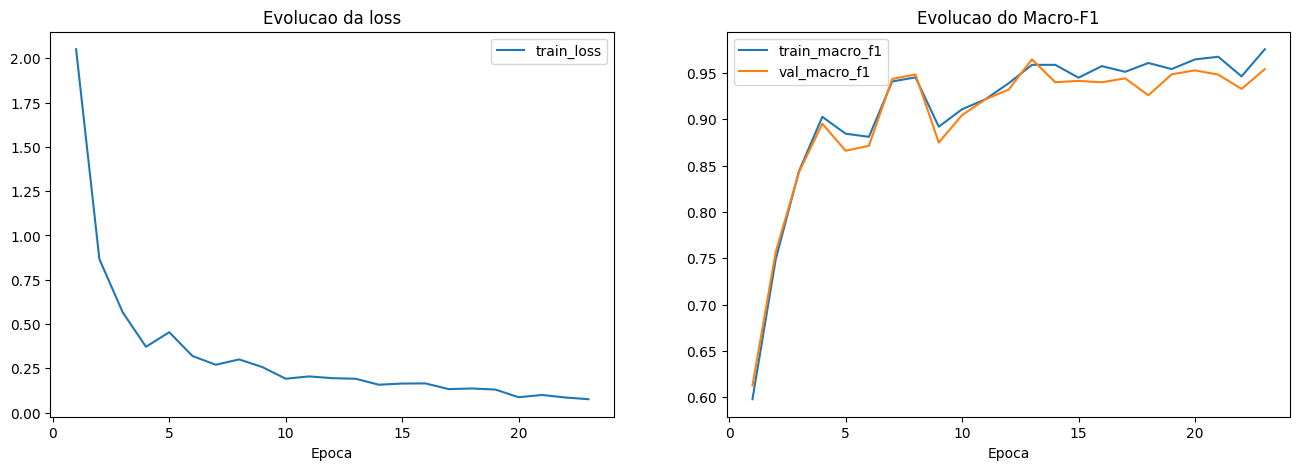

In [5]:
history = pd.read_csv(training_summary.history_path)
display(history.tail())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(history["epoch"], history["train_loss"], label="train_loss")
axes[0].set_title("Evolucao da loss")
axes[0].set_xlabel("Epoca")
axes[0].legend()

axes[1].plot(history["epoch"], history["train_macro_f1"], label="train_macro_f1")
axes[1].plot(history["epoch"], history["val_macro_f1"], label="val_macro_f1")
axes[1].set_title("Evolucao do Macro-F1")
axes[1].set_xlabel("Epoca")
axes[1].legend()
plt.show()

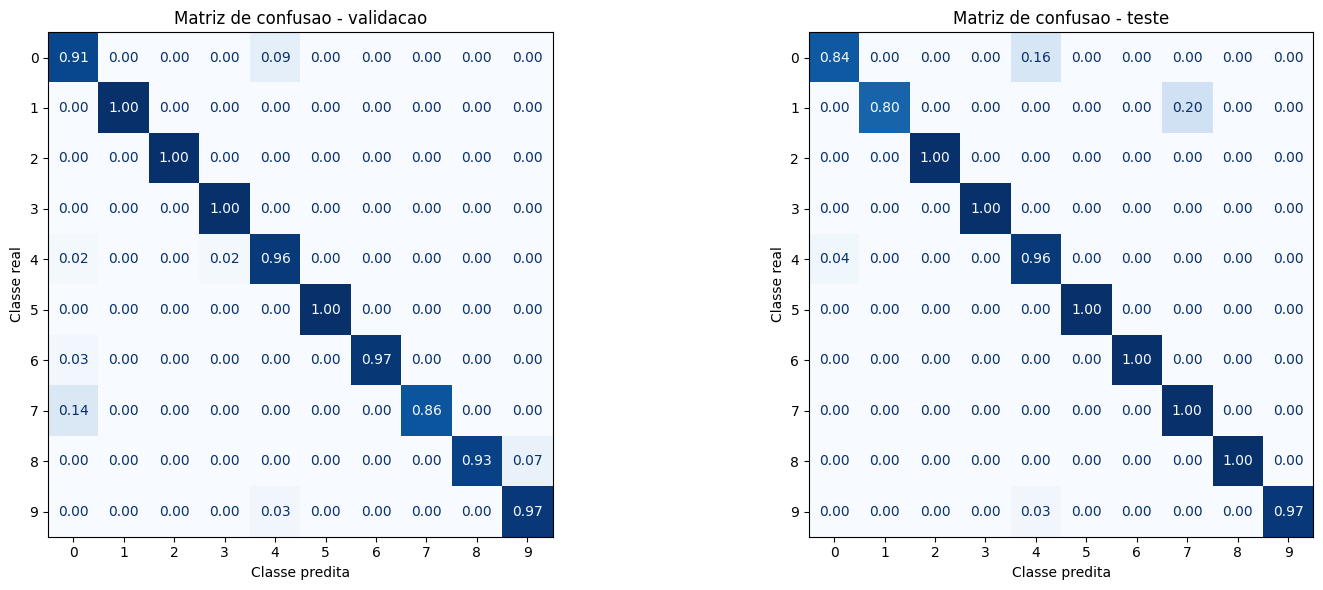

,label,precision,recall,f1-score,support
0,0,0.974026,0.842697,0.903614,89.000000
1,1,1.000000,0.800000,0.888889,20.000000
2,2,1.000000,1.000000,1.000000,5.000000
3,3,1.000000,1.000000,1.000000,16.000000
4,4,0.769231,0.961538,0.854701,52.000000
5,5,1.000000,1.000000,1.000000,68.000000
6,6,1.000000,1.000000,1.000000,33.000000
7,7,0.636364,1.000000,0.777778,7.000000
8,8,1.000000,1.000000,1.000000,14.000000
9,9,1.000000,0.967742,0.983607,31.000000


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_confusion_matrix_for_predictions(
    validation_arrays["y"],
    validation_pred,
    bundle.class_labels,
    normalize="true",
    title="Matriz de confusao - validacao",
    ax=axes[0],
)
plot_confusion_matrix_for_predictions(
    test_arrays["y"],
    test_pred,
    bundle.class_labels,
    normalize="true",
    title="Matriz de confusao - teste",
    ax=axes[1],
)
plt.tight_layout()
plt.show()

display(test_eval["classification_report_df"])

## Leitura final

Se a `versao10` superar a `versao9`, isso indicara que o ganho veio da incorporacao mais fiel da estrutura do dataset. Se ela tambem superar `RandomForest` e `XGBoost`, o resultado sera ainda mais forte: significara que a informacao temporal e operacional do `3W` pode, de fato, compensar a enorme forca das descricoes tabulares agregadas.